## CS 598 PSL Fall 2026
### Coding Assignment 1

- Anirudh Eswara
- Ryan Lenea
- Mark Synowiec
- Robert Walker

The [Banknote Authentication Dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) was used for this assignment.

This data set contains 1,372 samples of genuine and forged banknote-like specimens. Features
were extracted from images using a Wavelet Transform tool, resulting in 4 continuous
features:

1. variance of wavelet transformed image
2. skewness of wavelet transformed image
3. curtosis of wavelet transformed image
4. entropy of image

The response is a binary class label (0 = genuine, 1 = forged). There are no missing values.

In [1]:
# first install the ucimlrepo package:
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 
  
# data (as pandas dataframes) 
X = banknote_authentication.data.features 
y = banknote_authentication.data.targets 
  
# metadata 
print(banknote_authentication.metadata) 
  
# variable information 
print(banknote_authentication.variables) 

{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

### Problem 1

Data preparation: Use a random 70% / 30% train–test split of the full data set. Set the random seed to 598 for reproducibility of the split.

Our goal is to compare the performance of a simple linear regression and a k-nearest neighbor classification approach on the data. Use a naive approach for the linear regression in which you treat the response as continuous and then convert the continuous predictions to a binary classifier by thresholding at 0.5. For the kNN approach, use k = 1 : 20.

(a) [35 points] Plot the two errors (misclassification rate on the test set) against the corresponding k values. Make sure that you annotate the plots (e.g., using different colors or types of line) and add legends as needed. Also report the test error of the naive linear regression classifier as a horizontal reference line on the same plot.

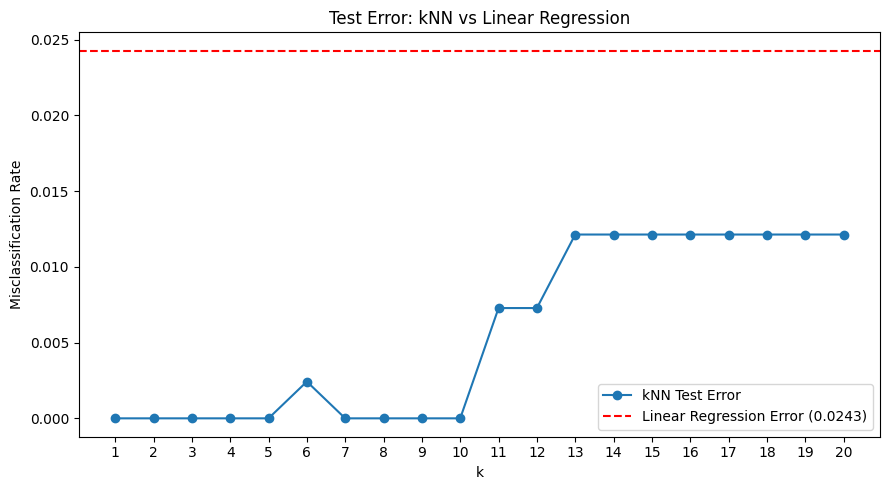

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection
import sklearn.linear_model
import sklearn.neighbors

# 70/30 train-test split with seed 598
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=598)

# Naive linear regression: treat class as continuous, threshold at 0.5
lr = sklearn.linear_model.LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = (lr.predict(X_test) >= 0.5).astype(int)
lr_error = np.mean(y_pred_lr != y_test.values)

# kNN for k = 1..20
knn_errors = []
knn_errors2 = []
for k in range(1, 21):
    #print(k)
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train.values.ravel())
    knn_errors.append(np.mean(knn.predict(X_test) != y_test.values.ravel()))

# Plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, 21), knn_errors, marker='o', label='kNN Test Error')
plt.axhline(lr_error, color='red', linestyle='--', label=f'Linear Regression Error ({lr_error:.4f})')
plt.xlabel('k')
plt.ylabel('Misclassification Rate')
plt.title('Test Error: kNN vs Linear Regression')
plt.xticks(range(1, 21))
plt.legend()
plt.tight_layout()
plt.show()


(b) [15 points] Does the plot match (approximately) your intuition of the bias–variance tradeoff in terms of having a U-shaped error? What is the optimal k value based on this result? For the optimal k, what are the corresponding degrees-of-freedom and its error? Discuss.

The KNN error is not u-shaped in this instance, but instead generally trends upward from zero. Investigating the data, our non-standard shape is likely because the data is so nicely differentiated. In the graph below, for example, we see that variance vs skewedness is barely overlapping, indicating distinct grouping. The ideal k is 1 (up to 10 not including 6) with df = n/k and error = 0.

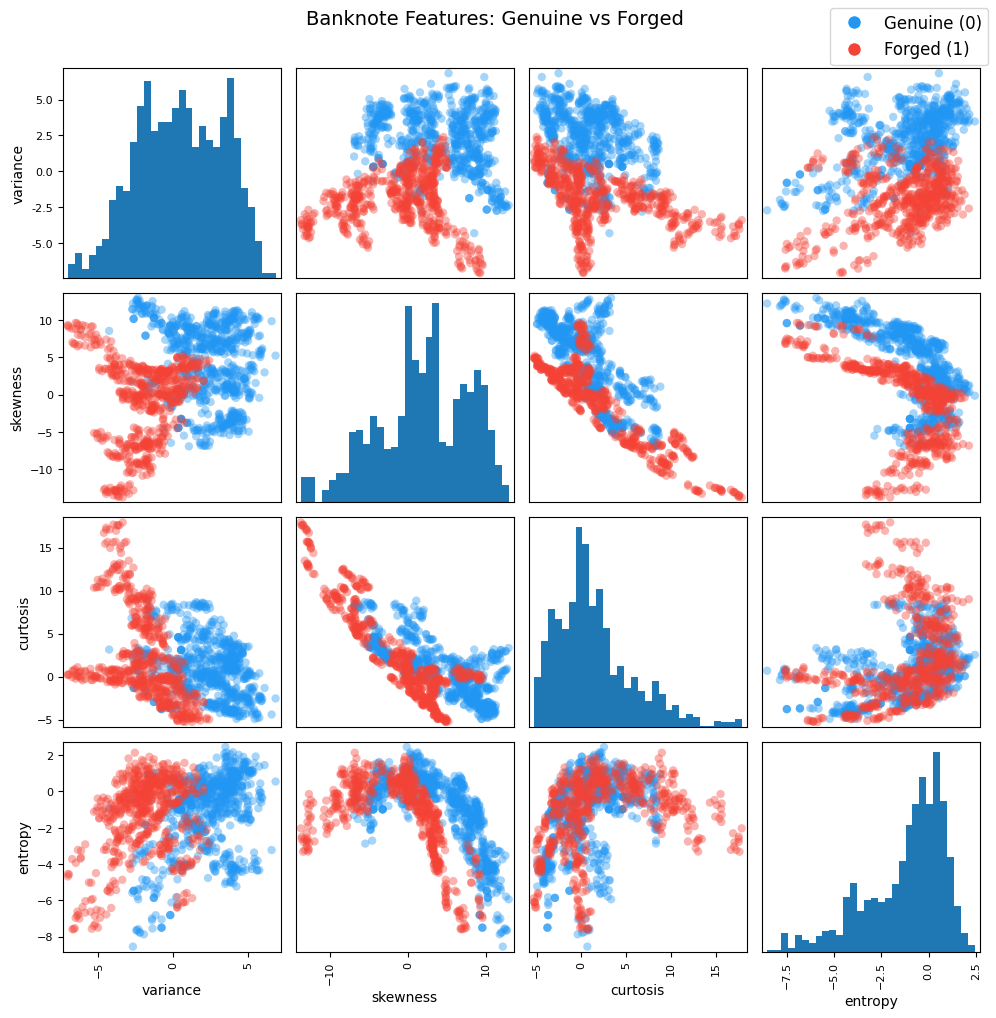

In [3]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import pandas as pd

df_plot = X.copy()
df_plot['class'] = y['class'].values
colors = df_plot['class'].map({0: '#2196F3', 1: '#F44336'})  # blue=genuine, red=forged

scatter_matrix(
    df_plot.drop(columns='class'),
    c=colors,
    figsize=(10, 10),
    alpha=0.4,
    diagonal='hist',
    marker='o',
    hist_kwds={'bins': 30}
)

# Add a manual legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Genuine (0)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=10, label='Forged (1)'),
]
plt.gcf().legend(handles=legend_elements, loc='upper right', fontsize=12)
plt.suptitle('Banknote Features: Genuine vs Forged', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Problem 2

The goal in this problem is to write your very own kNN function!

(a) [5 points] Generate 3 independent standard Normal variables X1,X2,X3 of n = 1000 independent observations. Generate the response Y from the following nonlinear model:
Y = X1 + 2 · X2 − X3 + 0.5 · X1X2 + ε where the errors ε are IID N(0, 1). Set the random seed to 598 for reproducibility.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

RANDOM_SEED = 598
n = 1000

rng = np.random.default_rng(RANDOM_SEED)

X1 = rng.standard_normal(n)
X2 = rng.standard_normal(n)
X3 = rng.standard_normal(n)
epsilon = rng.standard_normal(n)

y = X1 + 2*X2 - X3 + 0.5 * X1 * X2 + epsilon

# formatting data
X_features = np.column_stack([X1, X2, X3])

# train-test split
X_train = X_features[:500]
X_test = X_features[500:]
y_train = y[:500]
y_test = y[500:]

# knn
ks = [1,5,10,20]


(b) [10 points] Use the appropriate built-in kNN function in R or Python (Euclidean distance) and report the mean squared error (MSE) on the test set for k = 1, 5, 10, 20. Use the first 500 observations as the training data and the remaining 500 as the testing data.

In [5]:
from sklearn import neighbors
import numpy as np
import matplotlib.pyplot as plt

mse = []
for n in ks:
    knn = neighbors.KNeighborsRegressor(n_neighbors=n, metric="euclidean")
    knn.fit(X_train, y_train)
    y_predicted = knn.predict(X_test)
    mse.append(mean_squared_error(y_test, y_predicted))


(c) [35 points] For this question, you cannot load any additional packages. Write your own kNN function mykNN(xtrain, ytrain, xtest, k) that fits a kNN model and predicts multiple target points xtest. The function should return ytest.

Notes:

- xtrain is the training data set feature matrix
- ytrain is the training data set response vector
- xtest is the testing data set feature matrix
- ytest is the testing data set vector of predictors

Test your implementation by computing the MSE on the testing data for the same values k = 1, 5, 10, 20. Your results should be very close to those obtained with the built-in function in part (b).

Recall that the MSE is defined as
$MSE = {\frac 1 n} \sum\limits_{i=1}^n (y_i − \hat{y}_i)^2$

In [6]:
import math
from sklearn.metrics import mean_squared_error

def mykNN(xtrain: pd.DataFrame, ytrain: np.NDArray, xtest: pd.DataFrame, k: int):
    #distance function, finds sqrt(sum of (feature dist)^2)
    def dist(x1, x2):
        sum = 0
        for c1, c2 in zip(x1,x2):
            sum += math.pow(c1 - c2, 2)
        return math.sqrt(sum)

    ytest = []
    for x in xtest:
        #holds distance between points
        nearest = []
        #holds class
        nearest_y = []
        for xt, yt in zip(xtrain, ytrain):
            d = dist(x, xt)
            nearest.append(d)
            nearest_y.append(yt)
        nearest_df = pd.DataFrame({"distance": nearest,
                                   "class": nearest_y})
        
        ytest.append(np.mean(nearest_df.sort_values(by="distance").reset_index(drop=True).head(k)["class"].tolist()))
    return ytest

myknn_mse = []
for n in ks:
    myknn_mse.append(mean_squared_error(y_test, mykNN(X_train, y_train, X_test, n)))

at k=1, knn mse=2.137434033135611, myknn mse=2.137434033135611
at k=5, knn mse=1.2557219486509494, myknn mse=1.2557219486509494
at k=10, knn mse=1.3165233285736346, myknn mse=1.3165233285736346
at k=20, knn mse=1.3744529075777352, myknn mse=1.3744529075777352


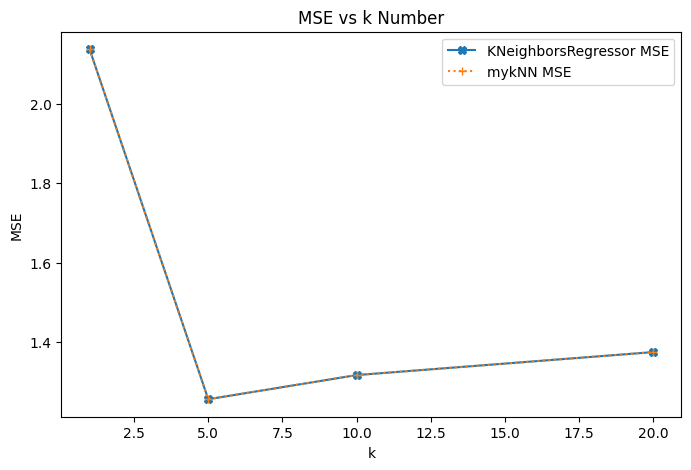

In [7]:
for n, knn_mse, m_mse in zip(ks, mse, myknn_mse):
    print(f"at k={n}, knn mse={knn_mse}, myknn mse={m_mse}")

plt.figure(figsize=(8,5))
plt.title('MSE vs k Number')
plt.plot(ks, mse, marker='X', label="KNeighborsRegressor MSE")
plt.plot(ks, myknn_mse, marker='+', linestyle=":", label="mykNN MSE")
plt.xlabel('k')
plt.ylabel('MSE')
plt.legend()
plt.show()